# Explainable Loan Approval Prediction Using Machine Learning

## Project Overview

This project investigates how machine-learning predictions can be interpreted using Explainable Artificial Intelligence (XAI) techniques. A Decision Tree classifier is used to predict loan-approval outcomes based on a synthetic dataset containing applicant characteristics such as income, loan amount, credit history, education, and self-employment status.

The project begins by developing an initial synthetic dataset and evaluating the predictive performance of the model. Although the initial model achieves high classification accuracy, further analysis reveals severe class imbalance in the generated dataset. This demonstrates how overall accuracy can provide a misleading representation of model performance when one outcome class dominates the dataset.

To address this limitation, a second experiment modifies the synthetic data-generation process to create a more informative distribution of approved and rejected applications. The Decision Tree model is then retrained and evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

The project subsequently applies two Explainable Artificial Intelligence techniques: Permutation Importance and SHAP (SHapley Additive exPlanations). Permutation Importance is used to examine global feature importance, while SHAP is used to investigate both global model behavior and individual predictions.

Three individual SHAP case studies are examined: a confidently rejected applicant, a confidently approved applicant, and a borderline applicant with equal predicted probabilities for approval and rejection. These cases demonstrate how different features can contribute positively or negatively to individual model predictions and how local explanations may differ from global feature-importance patterns.

Finally, global SHAP results are compared with Permutation Importance to examine the extent to which different XAI techniques agree about feature importance. The project demonstrates the importance of combining predictive-performance evaluation with explainability methods when analyzing machine-learning models.

Because the dataset used in this project is synthetically generated, the results are intended to demonstrate machine-learning and XAI methodology rather than represent real-world lending behavior or causal relationships.

## 1. Environment Setup and Libraries

This section imports the Python libraries required for data generation, data analysis, visualization, machine-learning model development, performance evaluation, and explainable artificial intelligence.

The project uses NumPy and pandas for data processing, Matplotlib for visualization, scikit-learn for preprocessing, model development, and evaluation, and SHAP for explainability analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance

Finished environment setup, python setup, and library setup

## 2. Experiment 1: Initial Synthetic Dataset

The first experiment creates a synthetic loan-approval dataset containing 700 observations. Each observation represents an applicant and includes five input features:

- income
- loan amount
- credit history
- education
- self-employment status

The target variable, `approved`, represents the simulated loan outcome, where 1 indicates approval and 0 indicates rejection.

The initial data-generation process assigns different weights to the applicant features and converts the resulting score into an approval probability using a logistic function. Random noise is included to prevent the simulated outcomes from following completely deterministic rules.

This first experiment is retained as a baseline because it later reveals an important limitation: the generated target variable becomes severely imbalanced. That imbalance provides a useful example of why overall accuracy should not be interpreted without also examining class distribution and class-specific performance metrics.

In [2]:
rng = np.random.default_rng(42)
n = 700

df = pd.DataFrame({
    "income": rng.integers(20000, 130000, n),
    "loan_amount": rng.integers(1000, 55000, n),
    "credit_history": rng.choice([0, 1], n, p=[0.28, 0.72]),
    "education": rng.choice(["Graduate", "Not Graduate"], n, p=[0.62, 0.38]),
    "self_employed": rng.choice(["Yes", "No"], n, p=[0.18, 0.82]),
})

base = (
    1.2*(df["credit_history"] == 1).astype(float) +
    0.8*(df["income"] > 45000).astype(float) +
    0.6*(df["loan_amount"] < 35000).astype(float) +
    0.2*(df["education"] == "Graduate").astype(float) -
    0.3*(df["self_employed"] == "Yes").astype(float)
)

noise = rng.normal(0, 0.55, n)
prob = 1/(1 + np.exp(-(base + noise)))

df["approved"] = (prob > 0.5).astype(int)

df.head()

,income,loan_amount,credit_history,education,self_employed,approved
0,29817,29109,0,Graduate,No,1
1,105135,34272,1,Graduate,Yes,1
2,92002,10056,0,Not Graduate,No,1
3,68276,10249,1,Graduate,No,1
4,67631,7984,1,Graduate,No,1


Dataset Created

### 2.1 Model Training and Initial Evaluation

The synthetic dataset is divided into training and testing subsets so that the model can be trained on one portion of the data and evaluated on observations it has not seen during training.

A Decision Tree classifier is used as the predictive model. Before training, categorical features such as education and self-employment status are converted into numerical representations using one-hot encoding. Numerical features are passed through the preprocessing pipeline without categorical encoding.

The preprocessing steps and Decision Tree classifier are combined into a scikit-learn pipeline. This ensures that the same transformations are applied consistently during both model training and prediction.

After training, the model is evaluated on the test set using classification metrics including accuracy, precision, recall, and F1-score. The distribution of predicted and actual classes is also examined to determine whether overall accuracy provides an accurate representation of model performance.

This evaluation reveals an important problem with Experiment 1: although the model achieves very high overall accuracy, the dataset contains very few rejected applications. The severe class imbalance makes the accuracy value misleading and motivates the development of Experiment 2.

In [3]:
X = df.drop(columns=["approved"])
y = df["approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 525
Testing rows: 175


splitting done

In [4]:
cat_cols = ["education", "self_employed"]
num_cols = ["income", "loan_amount", "credit_history"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

print("Preprocessing step created successfully.")

Preprocessing step created successfully.


In [5]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", tree)
])

pipe.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [6]:
pred = pipe.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.67      0.50      0.57         4
           1       0.99      0.99      0.99       171

    accuracy                           0.98       175
   macro avg       0.83      0.75      0.78       175
weighted avg       0.98      0.98      0.98       175



In [7]:
result = permutation_importance(
    pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances = result.importances_mean

feature_names = X_test.columns

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp

,feature,importance
2,credit_history,0.009143
0,income,0.008000
4,self_employed,0.005714
1,loan_amount,0.000000
3,education,0.000000


In [8]:
df["approved"].value_counts()

approved
1    686
0     14
Name: count, dtype: int64

### 2.2 Class Imbalance and the Accuracy Problem

Although the initial Decision Tree achieved approximately 98% accuracy, examining the target distribution revealed a severe class imbalance.

Out of 700 observations, 686 were classified as approved and only 14 as rejected. This corresponds to approximately 98% approvals and 2% rejections.

This imbalance makes overall accuracy potentially misleading. A classifier that simply predicted nearly every observation as approved could achieve a very high accuracy without learning to identify rejected applications effectively.

The class-specific evaluation supports this concern. Because rejected applications were extremely rare, performance metrics for class 0 were based on only a small number of test observations. Therefore, the approximately 98% accuracy from Experiment 1 should not be interpreted as evidence of a highly effective classifier.

This finding motivated a second experiment with a more informative class distribution. Rather than attempting to maximize accuracy, Experiment 2 was designed to provide enough observations from both classes to evaluate the model and its explanations more meaningfully.

## Experiment 1: Initial Imbalanced Dataset

The initial synthetic dataset contained 700 loan applications. Of these, 686 applications were approved and only 14 were rejected.
Although the Decision Tree achieved approximately 98% accuracy, the extreme class imbalance made accuracy an unreliable measure of model performance. This experiment demonstrates the importance of examining class distributions and class-specific evaluation metrics before interpreting overall model accuracy.
The results from Experiment 1 are retained as a baseline for comparison with an improved data-generation approach in Experiment 2.

# Experiment 2: Improved Synthetic Dataset

The initial experiment produced a severely imbalanced target distribution, with 686 approved applications and only 14 rejected applications.
In Experiment 2, the synthetic data-generation process is adjusted to produce a more meaningful class distribution. This allows the model to be evaluated on both approved and rejected applications more reliably.

In [9]:
# Test how different intercepts affect the approval rate

intercepts = [0.0, -0.5, -1.0, -1.5, -2.0]

for intercept in intercepts:

    adjusted_score = intercept + base + noise

    adjusted_prob = 1 / (1 + np.exp(-adjusted_score))

    adjusted_approved = (adjusted_prob > 0.5).astype(int)

    approval_rate = adjusted_approved.mean()

    print(
        "Intercept:", intercept,
        "| Approval rate:", round(approval_rate * 100, 2), "%"
    )

Intercept: 0.0 | Approval rate: 98.0 %
Intercept: -0.5 | Approval rate: 93.71 %
Intercept: -1.0 | Approval rate: 84.0 %
Intercept: -1.5 | Approval rate: 68.14 %
Intercept: -2.0 | Approval rate: 49.14 %


## 3. Experiment 2: Improved Class Distribution

The initial experiment revealed that the synthetic data-generation process produced a severely imbalanced target variable. To create a more informative classification problem, a second experiment was developed by adjusting the intercept used in the synthetic approval function.

Several intercept values were examined to determine how they affected the overall approval rate. As the intercept decreased, the simulated probability of approval also decreased. An intercept of -1.5 was selected because it produced a substantially more useful distribution of the two outcome classes while still retaining more approved than rejected observations.

Using this intercept, the second dataset contained 477 approved applications (approximately 68.14%) and 223 rejected applications (approximately 31.86%) out of 700 observations.

The purpose of this adjustment was not to reproduce a real-world lending approval rate. Instead, it created a controlled experimental dataset containing enough observations from both classes to support more meaningful model evaluation and explainability analysis.

The original five input features and their generated values were retained. Only the target outcome was regenerated using the adjusted intercept. This allows the second experiment to focus on how changing the class distribution affects model evaluation and subsequent XAI analysis.

In [10]:
# Create Experiment 2 dataset
df2 = df.drop(columns=["approved"]).copy()

intercept = -1.5

score2 = intercept + base + noise
prob2 = 1 / (1 + np.exp(-score2))

df2["approved"] = (prob2 > 0.5).astype(int)

print("Experiment 2 class distribution:")
print(df2["approved"].value_counts())

print("\nPercentages:")
print(df2["approved"].value_counts(normalize=True) * 100)

Experiment 2 class distribution:
approved
1    477
0    223
Name: count, dtype: int64

Percentages:
approved
1    68.142857
0    31.857143
Name: proportion, dtype: float64


### 3.1 Train-Test Split

The Experiment 2 dataset is divided into training and testing subsets using a 75/25 split. This produces 525 training observations and 175 testing observations.

Stratified sampling is used during the split so that the class proportions in the training and testing sets remain similar to the overall Experiment 2 class distribution.

The training set contains 358 approved applications and 167 rejected applications, while the test set contains 119 approved applications and 56 rejected applications.

Maintaining both classes in the training and testing subsets provides a more meaningful basis for evaluating the classifier than the highly imbalanced first experiment.

In [11]:
X2 = df2.drop(columns=["approved"])
y2 = df2["approved"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.25,
    random_state=42,
    stratify=y2
)

print("Training rows:", len(X2_train))
print("Testing rows:", len(X2_test))

print("\nTraining class distribution:")
print(y2_train.value_counts())

print("\nTesting class distribution:")
print(y2_test.value_counts())

Training rows: 525
Testing rows: 175

Training class distribution:
approved
1    358
0    167
Name: count, dtype: int64

Testing class distribution:
approved
1    119
0     56
Name: count, dtype: int64


### 3.2 Final Decision Tree Model

A Decision Tree classifier is trained on the Experiment 2 training data. The tree depth is limited to four levels to reduce model complexity and make the resulting decision process more suitable for explainability analysis.

The same preprocessing pipeline developed earlier is used to transform categorical variables and preserve numerical variables. Combining preprocessing and classification within a single pipeline ensures that identical transformations are applied during training, prediction, and subsequent explainability analysis.

A fixed random state of 42 is used to make the experiment reproducible.

In [12]:
tree2 = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

pipe2 = Pipeline(steps=[
    ("prep", preprocess),
    ("model", tree2)
])

pipe2.fit(X2_train, y2_train)

print("Experiment 2 model training complete.")

Experiment 2 model training complete.


In [13]:
pred2 = pipe2.predict(X2_test)

print("Experiment 2 Classification Report:")
print(classification_report(y2_test, pred2))

Experiment 2 Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.75      0.71        56
           1       0.88      0.82      0.85       119

    accuracy                           0.80       175
   macro avg       0.77      0.79      0.78       175
weighted avg       0.81      0.80      0.80       175



### 3.3 Experiment 2 Model Performance

The Experiment 2 Decision Tree achieved an overall test accuracy of approximately 80%.

Unlike the initial experiment, the model can now be evaluated meaningfully for both outcome classes. For rejected applications (class 0), the model achieved a precision of approximately 0.67, recall of 0.75, and F1-score of 0.71. For approved applications (class 1), precision was approximately 0.88, recall was 0.82, and the F1-score was approximately 0.85.

Although the overall accuracy is lower than the approximately 98% obtained in Experiment 1, the Experiment 2 results provide a more informative assessment because the test set contains substantially more observations from the rejection class.

For this reason, the Experiment 2 model is used as the primary model for the explainability analyses that follow.

## 4. Global Explainability Using Permutation Importance

Permutation Importance is used to examine which original input features the trained Decision Tree relies on most strongly across the Experiment 2 test set.

The method measures the change in model performance that occurs when the values of one feature are randomly shuffled while the remaining features are left unchanged. If shuffling a feature causes a substantial decrease in predictive performance, the model is considered to depend strongly on that feature.

Because the permutation analysis is applied to the complete preprocessing and classification pipeline, the resulting importance values correspond to the original five input features rather than the one-hot encoded feature representation used internally by the model.

Permutation Importance provides a global explanation because it summarizes feature influence across the test dataset rather than explaining a single individual prediction.

In [14]:
result2 = permutation_importance(
    pipe2,
    X2_test,
    y2_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feat_imp2 = pd.DataFrame({
    "feature": X2_test.columns,
    "importance": result2.importances_mean
}).sort_values(by="importance", ascending=False)

feat_imp2

,feature,importance
2,credit_history,0.183429
0,income,0.052000
4,self_employed,0.007429
3,education,0.006857
1,loan_amount,-0.001143


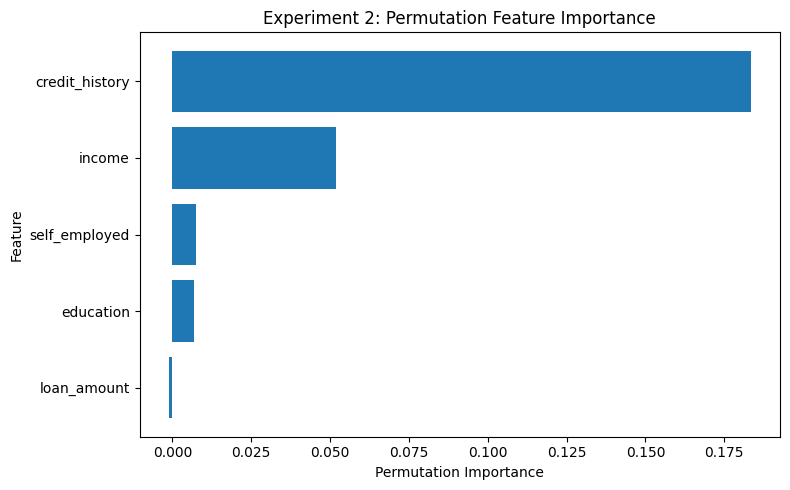

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    feat_imp2["feature"],
    feat_imp2["importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Experiment 2: Permutation Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("figures/permutation_importance.png", dpi=300, bbox_inches="tight")

plt.show()

### 4.1 Permutation Importance Results

The permutation analysis identified credit history as the most influential feature in the Experiment 2 model, followed by income.

Credit history produced the largest reduction in model performance when its values were shuffled, indicating that the classifier relies strongly on this feature when making predictions. Income also produced a measurable reduction in performance.

Self-employment status and education showed relatively small importance values. Loan amount produced an importance value close to zero in the permutation analysis, indicating that randomly shuffling this feature had little effect on overall test performance for the fitted Decision Tree.

A permutation importance value close to zero should not be interpreted as proof that a feature has no relationship with the target variable. Instead, it indicates that the fitted model's overall predictive performance did not depend strongly on that feature under this particular permutation experiment.

This distinction becomes important later when the permutation results are compared with SHAP, which measures feature influence using a different approach.

## Experiment 2 Results and Interpretation

Experiment 2 used an adjusted synthetic data-generation process to reduce the severe class imbalance observed in Experiment 1. The resulting dataset contained 477 approved applications (68.14%) and 223 rejected applications (31.86%). Using a stratified 75/25 train-test split, the test dataset contained 119 approved and 56 rejected applications.

The Decision Tree classifier achieved an overall accuracy of 80%. Unlike Experiment 1, the model demonstrated meaningful performance on both classes. For rejected applications, the model achieved a precision of 0.67, recall of 0.75, and F1-score of 0.71. For approved applications, precision was 0.88,recall was 0.82, and F1-score was 0.85.

Permutation feature importance identified credit history as the most influential feature (0.1834), followed by income (0.0520). Self employment and education showed relatively small importance values, while loan amount had an importance value close to zero.

The comparison with Experiment 1 demonstrates that high classification accuracy alone can be misleading when the target classes are severely imbalanced. Improving the class distribution resulted in lower overall accuracy but provided a more meaningful evaluation of model performance and clearer global feature importance.

In [16]:
import shap

print("SHAP version:", shap.__version__)
print("SHAP setup successful!")

SHAP version: 0.52.0
SHAP setup successful!


In [17]:
# Find applicants predicted as rejected
rejected_positions = np.where(pred2 == 0)[0]

print("Number predicted as rejected:", len(rejected_positions))
print("First few positions:", rejected_positions[:10])

Number predicted as rejected: 63
First few positions: [ 2  3  8 11 13 15 17 23 28 38]


In [18]:
rejected_position = np.where(pred2 == 0)[0][0]

applicant = X2_test.iloc[[rejected_position]]

print("Applicant position:", rejected_position)
print("\nApplicant information:")
display(applicant)

print("\nActual outcome:", y2_test.iloc[rejected_position])
print("Model prediction:", pred2[rejected_position])

probabilities = pipe2.predict_proba(applicant)[0]

print("\nProbability of rejection:", round(probabilities[0], 3))
print("Probability of approval:", round(probabilities[1], 3))

Applicant position: 2

Applicant information:


,income,loan_amount,credit_history,education,self_employed
579,31183,47734,1,Graduate,No



Actual outcome: 0
Model prediction: 0

Probability of rejection: 0.5
Probability of approval: 0.5


In [19]:
# Find rejection probabilities for all test applicants
all_probabilities = pipe2.predict_proba(X2_test)

rejection_probabilities = all_probabilities[:, 0]

# Only consider applicants predicted as rejected
rejected_positions = np.where(pred2 == 0)[0]

# Find the rejected applicant with the highest rejection probability
most_confident_position = rejected_positions[
    np.argmax(rejection_probabilities[rejected_positions])
]

confident_applicant = X2_test.iloc[[most_confident_position]]

print("Applicant position:", most_confident_position)

print("\nApplicant information:")
display(confident_applicant)

print("\nActual outcome:", y2_test.iloc[most_confident_position])
print("Model prediction:", pred2[most_confident_position])

print(
    "\nProbability of rejection:",
    round(rejection_probabilities[most_confident_position], 3)
)

print(
    "Probability of approval:",
    round(all_probabilities[most_confident_position, 1], 3)
)

Applicant position: 39

Applicant information:


,income,loan_amount,credit_history,education,self_employed
339,124818,45667,0,Not Graduate,No



Actual outcome: 0
Model prediction: 0

Probability of rejection: 1.0
Probability of approval: 0.0


In [20]:
# Transform the training data and selected applicant
X2_train_transformed = pipe2.named_steps["prep"].transform(X2_train)

applicant_transformed = pipe2.named_steps["prep"].transform(
    confident_applicant
)

# Get the transformed feature names
transformed_feature_names = (
    pipe2.named_steps["prep"].get_feature_names_out()
)

print("Original features:", X2_train.shape[1])
print("Transformed features:", len(transformed_feature_names))

print("\nTransformed feature names:")
print(transformed_feature_names)

Original features: 5
Transformed features: 7

Transformed feature names:
['cat__education_Graduate' 'cat__education_Not Graduate'
 'cat__self_employed_No' 'cat__self_employed_Yes' 'num__income'
 'num__loan_amount' 'num__credit_history']


## 5. Local Explainability Using SHAP

SHAP (SHapley Additive exPlanations) is used to explain individual predictions made by the Experiment 2 Decision Tree.

Unlike Permutation Importance, which provides a global measure of feature importance across the test dataset, SHAP estimates how individual feature values contribute to a specific model output relative to the model's baseline prediction.

Because the Decision Tree receives one-hot encoded categorical features, SHAP explanations are calculated using the transformed feature representation produced by the preprocessing pipeline.

Three local case studies are examined:

1. A confidently rejected applicant
2. A confidently approved applicant
3. A borderline applicant with equal approval and rejection probabilities

These cases are used to demonstrate how feature contributions can differ across individual predictions, even when the same trained model is used.

In [21]:
# Create a SHAP explainer for the trained Decision Tree
explainer = shap.TreeExplainer(pipe2.named_steps["model"])

# Calculate SHAP values for Applicant 339
shap_values = explainer(applicant_transformed)

print("SHAP values shape:", shap_values.values.shape)
print("Base values:", shap_values.base_values)
print("Model prediction probabilities:")
print(pipe2.predict_proba(confident_applicant))

SHAP values shape: (1, 7, 2)
Base values: [[0.31809524 0.68190476]]
Model prediction probabilities:
[[1. 0.]]


In [22]:
# SHAP contributions for the rejection class (class 0)
rejection_shap = shap_values.values[0, :, 0]

shap_table = pd.DataFrame({
    "feature": transformed_feature_names,
    "value": applicant_transformed[0],
    "SHAP_for_rejection": rejection_shap
})

shap_table["absolute_importance"] = shap_table[
    "SHAP_for_rejection"
].abs()

shap_table = shap_table.sort_values(
    by="absolute_importance",
    ascending=False
)

shap_table

,feature,value,SHAP_for_rejection,absolute_importance
6,num__credit_history,0.0,0.476506,0.476506
0,cat__education_Graduate,0.0,0.148009,0.148009
5,num__loan_amount,45667.0,0.139108,0.139108
4,num__income,124818.0,-0.057683,0.057683
2,cat__self_employed_No,1.0,-0.012195,0.012195
3,cat__self_employed_Yes,0.0,-0.011841,0.011841
1,cat__education_Not Graduate,1.0,0.000000,0.000000


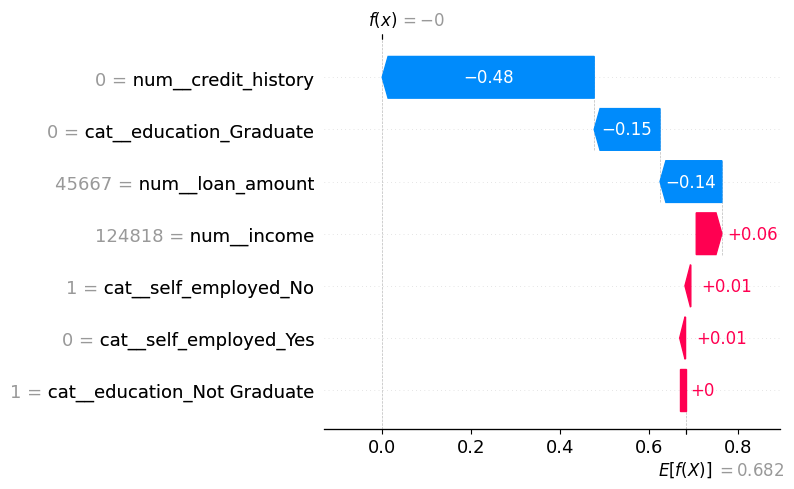

In [23]:
# Create SHAP explanation for the approval class (class 1)
approval_explanation = shap.Explanation(
    values=shap_values.values[0, :, 1],
    base_values=shap_values.base_values[0, 1],
    data=applicant_transformed[0],
    feature_names=transformed_feature_names
)

shap.plots.waterfall(approval_explanation, show=False)

plt.tight_layout()

plt.savefig(
    "figures/shap_rejection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Local SHAP Explanation - Applicant 339

Applicant 339 was correctly classified as rejected by the Decision Tree model, with a predicted approval probability of 0%.

The SHAP waterfall explanation shows that the model's baseline approval output was approximately 0.682. Credit history produced the largest negative contribution to the approval prediction (approximately -0.48). Education status and loan amount also contributed negatively (approximately -0.15 and -0.14, respectively).

In contrast, the applicant's income of $124,818 contributed positively to the approval prediction (approximately +0.06). However, this positive contribution was insufficient to offset the stronger negative contributions, particularly that associated with credit history.

This local explanation is consistent with the global permutation-importance analysis, which also identified credit history as the model's most influential feature. The result illustrates how global and local XAI techniques can provide complementary perspectives on model behavior.

Because the dataset is synthetic, these SHAP values explain the behavior of the trained model and should not be interpreted as causal relationships in real-world lending decisions.

In [24]:
# Find applicants predicted as approved
approved_positions = np.where(pred2 == 1)[0]

# Find the approved applicant with the highest approval probability
approval_probabilities = all_probabilities[:, 1]

most_confident_approved_position = approved_positions[
    np.argmax(approval_probabilities[approved_positions])
]

approved_applicant = X2_test.iloc[[most_confident_approved_position]]

print("Test-set position:", most_confident_approved_position)
print("Original dataset index:", approved_applicant.index[0])

print("\nApplicant information:")
display(approved_applicant)

print("\nActual outcome:",
      y2_test.iloc[most_confident_approved_position])

print("Model prediction:",
      pred2[most_confident_approved_position])

print(
    "\nProbability of rejection:",
    round(all_probabilities[most_confident_approved_position, 0], 3)
)

print(
    "Probability of approval:",
    round(all_probabilities[most_confident_approved_position, 1], 3)
)

Test-set position: 0
Original dataset index: 234

Applicant information:


,income,loan_amount,credit_history,education,self_employed
234,74203,24904,1,Not Graduate,No



Actual outcome: 1
Model prediction: 1

Probability of rejection: 0.021
Probability of approval: 0.979


In [25]:
# Transform Applicant 234 using the existing preprocessing pipeline
approved_applicant_transformed = pipe2.named_steps["prep"].transform(
    approved_applicant
)

# Calculate SHAP values
approved_shap_values = explainer(
    approved_applicant_transformed
)

print("SHAP values shape:", approved_shap_values.values.shape)

print(
    "Base approval value:",
    approved_shap_values.base_values[0, 1]
)

print(
    "Final approval probability:",
    pipe2.predict_proba(approved_applicant)[0, 1]
)

SHAP values shape: (1, 7, 2)
Base approval value: 0.6819047619047619
Final approval probability: 0.9791666666666666


In [26]:
# Get SHAP contributions for the approval class (class 1)
approved_class_shap = approved_shap_values.values[0, :, 1]

# Create a readable table
approved_shap_table = pd.DataFrame({
    "feature": transformed_feature_names,
    "value": approved_applicant_transformed[0],
    "SHAP_for_approval": approved_class_shap
})

# Calculate absolute importance for sorting
approved_shap_table["absolute_importance"] = (
    approved_shap_table["SHAP_for_approval"].abs()
)

# Sort from strongest to weakest contribution
approved_shap_table = approved_shap_table.sort_values(
    by="absolute_importance",
    ascending=False
)

approved_shap_table

,feature,value,SHAP_for_approval,absolute_importance
6,num__credit_history,1.0,0.180601,0.180601
5,num__loan_amount,24904.0,0.058045,0.058045
4,num__income,74203.0,0.032423,0.032423
3,cat__self_employed_Yes,0.0,0.014693,0.014693
2,cat__self_employed_No,1.0,0.012929,0.012929
0,cat__education_Graduate,0.0,-0.001429,0.001429
1,cat__education_Not Graduate,1.0,0.000000,0.000000


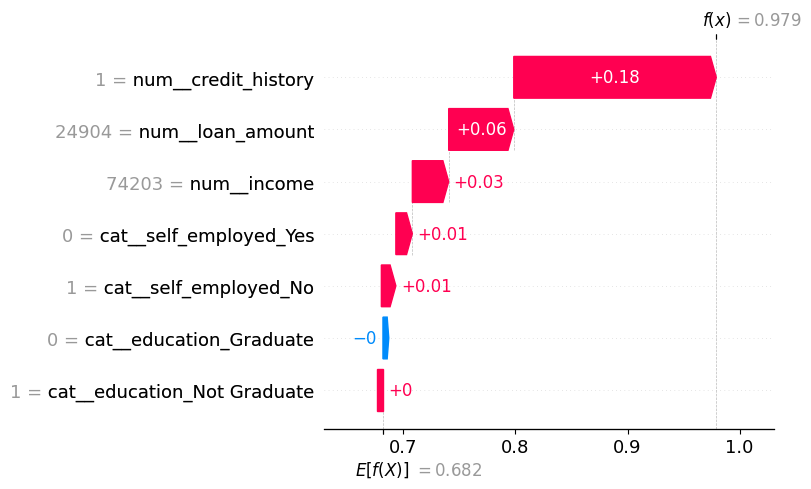

In [27]:
# Create approval-class SHAP explanation for Applicant 234

approved_explanation_234 = shap.Explanation(
    values=approved_shap_values.values[0, :, 1],
    base_values=approved_shap_values.base_values[0, 1],
    data=approved_applicant_transformed[0],
    feature_names=transformed_feature_names
)

shap.plots.waterfall(approved_explanation_234, show=False)

plt.tight_layout()

plt.savefig(
    "figures/shap_approval.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Local SHAP Explanation - Applicant 234

Applicant 234 was correctly classified as approved by the Decision Tree model, with a predicted approval probability of approximately 97.9%.

The SHAP waterfall explanation shows that the model's baseline approval output was approximately 0.682. Credit history produced the largest positive contribution to the approval prediction (approximately +0.18). Loan amount and income also contributed positively, by approximately +0.06 and +0.03,respectively.

The remaining features had relatively small effects on the prediction. Together,the feature contributions increased the model output from the baseline of approximately 0.682 to a final approval probability of approximately 0.979.

This result complements the explanation for Applicant 339. In both cases, credit history produced the largest local SHAP contribution, but in opposite directions. This is also consistent with the global permutation-importance analysis, which identified credit history as the most influential feature in the model.

Because the dataset is synthetic, these explanations describe the behavior of the trained model and should not be interpreted as causal relationships in real-world lending decisions.

In [28]:
# Case Study 3: Borderline Applicant

borderline_position = 2
borderline_applicant = X2_test.iloc[[borderline_position]]

print("Test-set position:", borderline_position)
print("Original dataset index:", borderline_applicant.index[0])

print("\nApplicant information:")
display(borderline_applicant)

print("\nActual outcome:",
      y2_test.iloc[borderline_position])

print("Model prediction:",
      pred2[borderline_position])

borderline_probabilities = pipe2.predict_proba(
    borderline_applicant
)[0]

print(
    "\nProbability of rejection:",
    round(borderline_probabilities[0], 3)
)

print(
    "Probability of approval:",
    round(borderline_probabilities[1], 3)
)

Test-set position: 2
Original dataset index: 579

Applicant information:


,income,loan_amount,credit_history,education,self_employed
579,31183,47734,1,Graduate,No



Actual outcome: 0
Model prediction: 0

Probability of rejection: 0.5
Probability of approval: 0.5


In [29]:
# Transform Applicant 579
borderline_applicant_transformed = pipe2.named_steps["prep"].transform(
    borderline_applicant
)

# Calculate SHAP values
borderline_shap_values = explainer(
    borderline_applicant_transformed
)

print(
    "Base approval value:",
    borderline_shap_values.base_values[0, 1]
)

print(
    "Final approval probability:",
    pipe2.predict_proba(borderline_applicant)[0, 1]
)

# Get SHAP contributions for approval class
borderline_approval_shap = borderline_shap_values.values[0, :, 1]

# Create SHAP table
borderline_shap_table = pd.DataFrame({
    "feature": transformed_feature_names,
    "value": borderline_applicant_transformed[0],
    "SHAP_for_approval": borderline_approval_shap
})

borderline_shap_table["absolute_importance"] = (
    borderline_shap_table["SHAP_for_approval"].abs()
)

borderline_shap_table = borderline_shap_table.sort_values(
    by="absolute_importance",
    ascending=False
)

borderline_shap_table

Base approval value: 0.6819047619047619
Final approval probability: 0.5


,feature,value,SHAP_for_approval,absolute_importance
4,num__income,31183.0,-0.232287,0.232287
6,num__credit_history,1.0,0.165182,0.165182
5,num__loan_amount,47734.0,-0.148647,0.148647
2,cat__self_employed_No,1.0,0.026715,0.026715
3,cat__self_employed_Yes,0.0,0.005338,0.005338
0,cat__education_Graduate,1.0,0.001795,0.001795
1,cat__education_Not Graduate,0.0,0.000000,0.000000


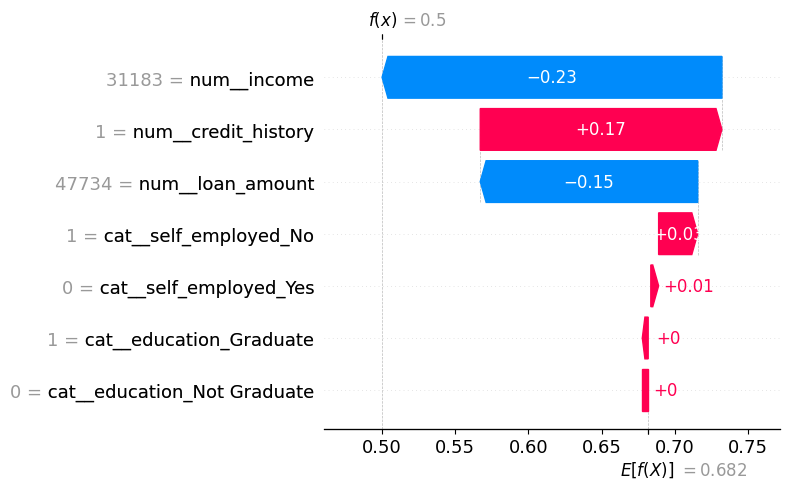

In [30]:
# Create approval-class SHAP explanation for Applicant 579

borderline_explanation = shap.Explanation(
    values=borderline_shap_values.values[0, :, 1],
    base_values=borderline_shap_values.base_values[0, 1],
    data=borderline_applicant_transformed[0],
    feature_names=transformed_feature_names
)

shap.plots.waterfall(borderline_explanation, show=False)

plt.tight_layout()

plt.savefig(
    "figures/shap_borderline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Local SHAP Explanation - Applicant 579 (Borderline Case)

Applicant 579 represents a borderline prediction. The Decision Tree assigned an approval probability of 0.50 and a rejection probability of 0.50. The applicant was ultimately classified as rejected.

The SHAP explanation shows that the model's baseline approval output was approximately 0.682. The applicant had an income of USD 31,183, which produced the largest negative contribution to approval, with a SHAP value of approximately -0.23. The loan amount of USD 47,734 produced another substantial negative contribution of approximately -0.15.

In contrast, the applicant's positive credit history produced a strong positive contribution toward approval, with a SHAP value of approximately +0.17. The self-employment-related features provided smaller positive contributions, while education had very little influence on this particular prediction.

These features pushed the prediction in opposite directions. Income and loan amount pushed the model toward rejection, while positive credit history pushed the model toward approval. After combining these competing effects with the smaller contributions from the remaining features, the model's approval probability decreased from the baseline of approximately 0.682 to exactly 0.50.

This case demonstrates an important distinction between global and local explainability. The global permutation importance analysis identified credit history as the most influential feature overall. However, for Applicant 579 specifically, income had the largest absolute SHAP contribution. This shows that a feature that is highly important across the entire dataset does not necessarily have the strongest influence on every individual prediction.

The borderline case also demonstrates the value of explainable AI. Looking only at the final 50% approval probability does not reveal why the model was uncertain. SHAP shows that the uncertainty resulted from competing feature contributions: positive credit history strongly supported approval, while income and loan amount pushed the prediction in the opposite direction.

Because the dataset used in this experiment is synthetic, these SHAP explanations describe the behavior of the trained Decision Tree model. They should not be interpreted as causal relationships or as conclusions about real-world lending decisions.

## 6. Global SHAP Analysis

After examining individual predictions, SHAP is applied across the entire Experiment 2 test set to evaluate global model behavior.

For each transformed feature, the mean absolute SHAP value is calculated across all 175 test observations. Absolute values are used because a feature may increase the model output for some applicants and decrease it for others. Averaging signed SHAP values directly could therefore cause positive and negative contributions to cancel each other out.

The resulting global SHAP analysis provides a second perspective on feature importance. Unlike Permutation Importance, which measures the reduction in predictive performance when a feature is shuffled, SHAP measures the average magnitude of each feature's contribution to individual model outputs.

A SHAP beeswarm plot is also used to visualize both the magnitude and direction of feature effects across the test dataset.

In [31]:
# GLOBAL SHAP ANALYSIS
# Transform the entire Experiment 2 test set

X2_test_transformed = pipe2.named_steps["prep"].transform(X2_test)

print("Original test data shape:", X2_test.shape)
print("Transformed test data shape:", X2_test_transformed.shape)

# Calculate SHAP values for all test applicants
global_shap_values = explainer(X2_test_transformed)

print("\nSHAP values shape:", global_shap_values.values.shape)

Original test data shape: (175, 5)
Transformed test data shape: (175, 7)

SHAP values shape: (175, 7, 2)


In [32]:
# GLOBAL SHAP FEATURE IMPORTANCE
# Use SHAP values for the approval class (class 1)

global_approval_shap = global_shap_values.values[:, :, 1]

# Calculate mean absolute SHAP value for each transformed feature
mean_abs_shap = np.abs(global_approval_shap).mean(axis=0)

# Create feature importance table
global_shap_importance = pd.DataFrame({
    "feature": transformed_feature_names,
    "mean_absolute_SHAP": mean_abs_shap
})

# Sort from most important to least important
global_shap_importance = global_shap_importance.sort_values(
    by="mean_absolute_SHAP",
    ascending=False
)

global_shap_importance

,feature,mean_absolute_SHAP
6,num__credit_history,0.256738
4,num__income,0.094441
5,num__loan_amount,0.089691
2,cat__self_employed_No,0.026178
3,cat__self_employed_Yes,0.023479
0,cat__education_Graduate,0.005021
1,cat__education_Not Graduate,0.000000


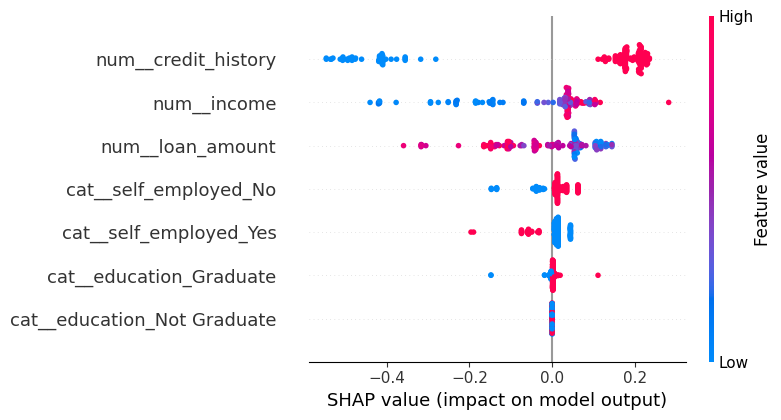

In [33]:
# Create SHAP Explanation for approval class across all test applicants

global_approval_explanation = shap.Explanation(
    values=global_shap_values.values[:, :, 1],
    base_values=global_shap_values.base_values[:, 1],
    data=X2_test_transformed,
    feature_names=transformed_feature_names
)

# Global SHAP beeswarm plot
shap.plots.beeswarm(
    global_approval_explanation,
    max_display=7,
    show=False
)

plt.tight_layout()

plt.savefig(
    "figures/shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Global SHAP Analysis

The SHAP beeswarm plot provides a global explanation of the Decision Tree model across all 175 observations in the test set. Each point represents an individual applicant, while the horizontal position represents the SHAP contribution of a feature to the model's approval output.

Credit history was the most influential feature globally. A credit history value of 0 generally produced large negative SHAP values, pushing predictions toward rejection, while a value of 1 generally produced positive SHAP values and pushed predictions toward approval.

Income and loan amount were the next most influential features. Lower income values generally produced negative contributions to approval, while higher income values tended to have more favorable effects. Higher loan amounts frequently produced negative contributions, whereas lower loan amounts tended to contribute more positively.

Self-employment status had a smaller overall influence, while education contributed very little to the model's predictions.

The global SHAP results generally support the permutation-importance analysis, particularly in identifying credit history as the dominant feature. However, the methods differed in their assessment of loan amount. Permutation importance assigned loan amount very little importance, whereas SHAP showed that loan amount could have meaningful effects on individual predictions. This difference illustrates that different explainability methods measure different aspects of model behavior.

Because this experiment uses synthetic data, these patterns describe the behavior of the trained model and should not be interpreted as causal relationships or conclusions about real-world lending decisions.

In [34]:
# Aggregate SHAP importance into original feature groups

shap_comparison = pd.DataFrame({
    "feature": [
        "credit_history",
        "income",
        "loan_amount",
        "self_employed",
        "education"
    ],
    
    "SHAP_importance": [
        global_shap_importance.loc[
            global_shap_importance["feature"] == "num__credit_history",
            "mean_absolute_SHAP"
        ].iloc[0],

        global_shap_importance.loc[
            global_shap_importance["feature"] == "num__income",
            "mean_absolute_SHAP"
        ].iloc[0],

        global_shap_importance.loc[
            global_shap_importance["feature"] == "num__loan_amount",
            "mean_absolute_SHAP"
        ].iloc[0],

        # Combine the two one-hot encoded self-employment columns
        global_shap_importance.loc[
            global_shap_importance["feature"].isin([
                "cat__self_employed_No",
                "cat__self_employed_Yes"
            ]),
            "mean_absolute_SHAP"
        ].sum(),

        # Combine the two one-hot encoded education columns
        global_shap_importance.loc[
            global_shap_importance["feature"].isin([
                "cat__education_Graduate",
                "cat__education_Not Graduate"
            ]),
            "mean_absolute_SHAP"
        ].sum()
    ]
})

shap_comparison = shap_comparison.sort_values(
    by="SHAP_importance",
    ascending=False
)

shap_comparison

,feature,SHAP_importance
0,credit_history,0.256738
1,income,0.094441
2,loan_amount,0.089691
3,self_employed,0.049657
4,education,0.005021


## 7. Comparison of Global XAI Methods

Permutation Importance and global SHAP are compared to determine whether the two explainability methods provide consistent conclusions about the trained Decision Tree.

Because the two methods produce importance values on different scales and measure different aspects of model behavior, the raw numerical values should not be compared directly. Instead, the analysis focuses primarily on feature rankings and the overall patterns identified by each method.

Both methods identify credit history as the most important feature and income as the second most important feature. However, differences appear in the rankings of loan amount and education. These differences illustrate that explainability methods can provide complementary rather than identical views of model behavior.

In [35]:
#  Permutation Importance for Experiment 2

perm_result2 = permutation_importance(
    pipe2,
    X2_test,
    y2_test,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

permutation_comparison = pd.DataFrame({
    "feature": X2_test.columns,
    "Permutation_importance": perm_result2.importances_mean
})

permutation_comparison = permutation_comparison.sort_values(
    by="Permutation_importance",
    ascending=False
)

permutation_comparison

,feature,Permutation_importance
2,credit_history,0.183810
0,income,0.049333
3,education,0.006286
4,self_employed,0.006095
1,loan_amount,0.003238


In [36]:
# Compare Permutation Importance and Global SHAP

xai_comparison = pd.merge(
    permutation_comparison,
    shap_comparison,
    on="feature"
)

# Add rankings for each method
xai_comparison["Permutation_rank"] = (
    xai_comparison["Permutation_importance"]
    .rank(ascending=False, method="min")
    .astype(int)
)

xai_comparison["SHAP_rank"] = (
    xai_comparison["SHAP_importance"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Arrange columns
xai_comparison = xai_comparison[
    [
        "feature",
        "Permutation_importance",
        "Permutation_rank",
        "SHAP_importance",
        "SHAP_rank"
    ]
]

# Sort by SHAP importance
xai_comparison = xai_comparison.sort_values(
    by="SHAP_importance",
    ascending=False
)

xai_comparison

,feature,Permutation_importance,Permutation_rank,SHAP_importance,SHAP_rank
0,credit_history,0.183810,1,0.256738,1
1,income,0.049333,2,0.094441,2
4,loan_amount,0.003238,5,0.089691,3
3,self_employed,0.006095,4,0.049657,4
2,education,0.006286,3,0.005021,5


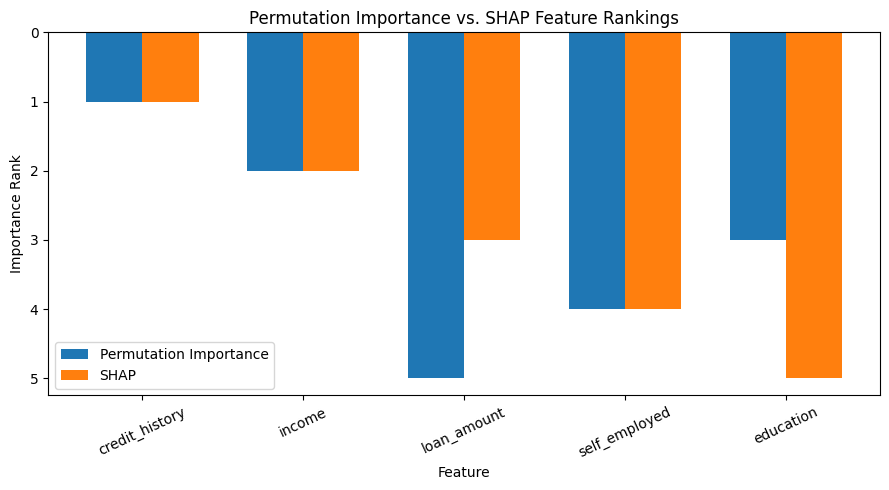

In [37]:
# Visualize Permutation Importance vs. SHAP rankings

rank_comparison = pd.DataFrame({
    "feature": [
        "credit_history",
        "income",
        "loan_amount",
        "self_employed",
        "education"
    ],
    "Permutation_rank": [1, 2, 5, 4, 3],
    "SHAP_rank": [1, 2, 3, 4, 5]
})

rank_comparison = rank_comparison.sort_values("SHAP_rank")

x = np.arange(len(rank_comparison))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    rank_comparison["Permutation_rank"],
    width,
    label="Permutation Importance"
)

plt.bar(
    x + width/2,
    rank_comparison["SHAP_rank"],
    width,
    label="SHAP"
)

plt.xticks(
    x,
    rank_comparison["feature"],
    rotation=25
)

plt.xlabel("Feature")
plt.ylabel("Importance Rank")
plt.title("Permutation Importance vs. SHAP Feature Rankings")

plt.gca().invert_yaxis()

plt.legend()
plt.tight_layout()

plt.savefig(
    "figures/xai_ranking_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Comparison of Permutation Importance and SHAP

The comparison between Permutation Importance and global SHAP shows substantial agreement between the two explainability methods. Both methods ranked credit history as the most important feature and income as the second most important feature. Self-employment status was also ranked fourth by both methods.

The main disagreement involved loan amount and education. Permutation Importance ranked education third and loan amount fifth, whereas SHAP ranked loan amount third and education fifth.

This difference does not necessarily indicate that either method is incorrect. The two approaches measure feature importance differently. Permutation Importance evaluates how much predictive performance decreases when the values of a feature are randomly shuffled. In contrast, SHAP measures how strongly each feature contributes to individual model outputs relative to a baseline prediction.

The difference is particularly important for loan amount. Although shuffling loan amount produced relatively little reduction in overall predictive performance, SHAP showed that loan amount could substantially influence individual predictions. This behavior was observed in the borderline case of Applicant 579, where loan amount produced a negative SHAP contribution of approximately -0.15.

Overall, the two methods provide consistent evidence that credit history and income are the dominant features in the trained model, while SHAP provides additional information about how feature effects vary across individual predictions.

Because the dataset is synthetic, these results describe the behavior of the experimental model and should not be interpreted as evidence about real-world lending decisions.

## 8. Final Model Performance Summary

Before concluding the experiment, the performance of the final Experiment 2 Decision Tree is summarized using accuracy, precision, recall, F1-score, and the confusion matrix.

The purpose of this summary is to consolidate the primary predictive-performance results used throughout the XAI analysis. These metrics should be considered together rather than relying on overall accuracy alone, particularly because the two outcome classes are not equally represented.

In [38]:
# FINAL MODEL PERFORMANCE SUMMARY

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Calculate Experiment 2 performance metrics
accuracy = accuracy_score(y2_test, pred2)

precision_rejected = precision_score(
    y2_test, pred2, pos_label=0
)

recall_rejected = recall_score(
    y2_test, pred2, pos_label=0
)

f1_rejected = f1_score(
    y2_test, pred2, pos_label=0
)

precision_approved = precision_score(
    y2_test, pred2, pos_label=1
)

recall_approved = recall_score(
    y2_test, pred2, pos_label=1
)

f1_approved = f1_score(
    y2_test, pred2, pos_label=1
)

# Display results
print("FINAL MODEL PERFORMANCE")
print("-----------------------")

print(f"Accuracy: {accuracy:.3f}")

print("\nRejected Class (0)")
print(f"Precision: {precision_rejected:.3f}")
print(f"Recall:    {recall_rejected:.3f}")
print(f"F1-score:  {f1_rejected:.3f}")

print("\nApproved Class (1)")
print(f"Precision: {precision_approved:.3f}")
print(f"Recall:    {recall_approved:.3f}")
print(f"F1-score:  {f1_approved:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y2_test, pred2))

FINAL MODEL PERFORMANCE
-----------------------
Accuracy: 0.800

Rejected Class (0)
Precision: 0.667
Recall:    0.750
F1-score:  0.706

Approved Class (1)
Precision: 0.875
Recall:    0.824
F1-score:  0.848

Confusion Matrix:
[[42 14]
 [21 98]]


### Final Model Performance

The final Decision Tree model achieved an overall test accuracy of 80.0% on the balanced experimental dataset.

For rejected applications (class 0), the model achieved a precision of 0.667, recall of 0.750, and F1-score of 0.706. For approved applications (class 1), the model achieved a precision of 0.875, recall of 0.824, and F1-score of 0.848.

The confusion matrix showed that 42 rejected applications and 98 approved applications were classified correctly. The model incorrectly classified 14 rejected applications as approved and 21 approved applications as rejected. Overall, 140 of the 175 test observations were classified correctly.

These results provide a more meaningful evaluation than the initial experiment, which achieved approximately 98% accuracy on a severely imbalanced dataset containing very few rejected applications. The second experiment reduced this imbalance and allowed model performance to be evaluated more meaningfully across both outcome classes.

Although the final model does not achieve perfect predictive performance, the purpose of this project is not to develop a production-ready lending system. Instead, the model provides a controlled experimental setting for investigating how explainable artificial intelligence methods can reveal global and local model behavior.

## 9. Limitations

This project has several limitations that should be considered when interpreting the results.

### I. Synthetic Dataset

The dataset used in this study was synthetically generated rather than collected from real lending applications. The relationships between income, loan amount, credit history, education, self-employment status, and loan approval were therefore defined by the experimental data-generation process.

As a result, the findings should not be interpreted as evidence about how these variables affect real-world lending decisions. The purpose of the synthetic dataset was to provide a controlled environment for studying machine-learning explainability.

### II. Limited Number of Features

The model uses only five original input features: income, loan amount, credit history, education, and self-employment status. Real lending systems may consider substantially more information and may involve more complex relationships between variables.

Therefore, the model represents a simplified classification problem rather than a realistic lending system.

### III. Single Predictive Model

The primary model used in the experiment was a Decision Tree classifier. Different machine-learning algorithms may learn different relationships from the same dataset and may produce different explanations.

Future work could compare explanations across models such as Random Forest, Gradient Boosting, or Logistic Regression.

### IV. Class Distribution

The initial experiment contained a severe class imbalance, with 686 approved observations and only 14 rejected observations. This produced approximately 98% accuracy but provided poor information about the model's ability to identify rejected applications.

A second experimental dataset was therefore created with a more useful class distribution of 477 approvals and 223 rejections. Although this improved the evaluation, the class distribution was still determined synthetically.

### V. XAI Methods Explain the Model, Not Causality

Permutation Importance and SHAP describe the behavior of the trained machine-learning model. They do not establish causal relationships between applicant characteristics and loan outcomes.

For example, a positive SHAP value for credit history indicates that the feature increased the model's output for a particular prediction relative to the model baseline. It does not demonstrate that changing credit history would necessarily cause the same change in a real-world lending decision.

### VI. Differences Between Explanation Methods

Permutation Importance and SHAP measure feature influence differently. Permutation Importance measures changes in predictive performance when a feature is shuffled, whereas SHAP measures feature contributions to model outputs relative to a baseline.

Consequently, the two methods do not necessarily produce identical feature rankings. This was observed for loan amount and education in this experiment.

## 10. Conclusion

This project investigated how explainable artificial intelligence techniques can be used to understand the predictions of a machine-learning classification model.

An initial Decision Tree model achieved approximately 98% accuracy; however, further analysis revealed that the dataset was severely imbalanced, containing 686 approved applications and only 14 rejected applications. This demonstrated why accuracy alone can provide a misleading assessment of classification performance.

A second experiment was therefore conducted using a more informative class distribution of 477 approved and 223 rejected observations. The resulting Decision Tree achieved an overall test accuracy of 80.0%, with an F1-score of 0.706 for rejected applications and 0.848 for approved applications.

Two explainability approaches were then applied to the final model. Permutation Importance provided a global measure of feature importance, while SHAP was used for both global and local explanations. Both methods identified credit history as the most influential feature and income as the second most influential feature. However, differences appeared in the rankings of loan amount and education, demonstrating that different XAI methods can provide complementary perspectives on model behavior.

Local SHAP analysis further demonstrated that global feature importance does not fully explain individual predictions. Confident approval, confident rejection, and borderline cases showed different combinations of feature contributions. In particular, the borderline case demonstrated how positive and negative feature effects can offset one another and move the model output toward the classification threshold.

Overall, the experiment demonstrates the value of combining predictive-performance evaluation with multiple explainability techniques. Model accuracy describes how frequently predictions are correct, while XAI methods provide additional information about why the model produces those predictions.

Because the experiment uses synthetic data and a simplified Decision Tree model, the results should be interpreted as an investigation of machine-learning explainability rather than as conclusions about real-world lending behavior.